# Ноутбук 2

## Задача

В урне находятся **6 красных и 6 синих шаров**. Из урны случайным образом одновременно выбирают **3 шара без возвращения**.

Рассмотреть событие **A**: «среди выбранных шаров ровно 2 красных и 1 синий».




Всего в урне 12 шаров: 6 красных и 6 синих. Из них выбираются 3.



In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import comb

p_theoretical = comb(6, 2) * comb(6, 1) / comb(12, 3)
print(f"Теоретическая вероятность: {p_theoretical:.4f}")

Теоретическая вероятность: 0.4091


Будем представлять красные шары числом 1, а синие — числом 0. При каждом испытании случайно выбираем 3 различных шара из массива из 12 элементов. Событие A происходит, если сумма выбранных значений равна 2.

In [20]:
def experiment():
    urn = np.array([1] * 6 + [0] * 6)
    selected = np.random.choice(urn, size=3, replace=False)
    return selected.sum() == 2

print("Результат одного испытания:", experiment())

Результат одного испытания: False


Проведём N случайных испытаний

$f_A = \frac{N_A}{N},$

$N_A$ — количество испытаний, в которых произошло событие A,
$N$ — общее число испытаний.

In [21]:
N = 10_000

results = [experiment() for _ in range(N)]
N_A = sum(results)
frequency = N_A / N

print(f"Количество испытаний: {N}")
print(f"Событие A произошло: {N_A} раз")
print(f"Относительная частота: {frequency:.4f}")
print(f"Теоретическая вероятность: {p_theoretical:.4f}")
print(f"Абсолютное отклонение: {abs(frequency - p_theoretical):.4f}")

Количество испытаний: 10000
Событие A произошло: 4100 раз
Относительная частота: 0.4100
Теоретическая вероятность: 0.4091
Абсолютное отклонение: 0.0009


Исследование сходимости:


In [22]:
N_values = np.linspace(100, 10_000, 51)
frequencies = []
errors = []

for N in N_values:
    N = int(N)
    results = [experiment() for _ in range(N)]
    frequency = sum(results) / N
    frequencies.append(frequency)
    errors.append(abs(frequency - p_theoretical))

df = pd.DataFrame({
    'N': N_values,
    'Теоретическая вероятность': [p_theoretical] * len(N_values),
    'Относительная частота': frequencies,
    'Абсолютное отклонение': errors
})

df

,N,Теоретическая вероятность,Относительная частота,Абсолютное отклонение
0,100.0,0.409091,0.380000,0.029091
1,298.0,0.409091,0.416107,0.007016
2,496.0,0.409091,0.370968,0.038123
3,694.0,0.409091,0.417867,0.008777
4,892.0,0.409091,0.412556,0.003465
5,1090.0,0.409091,0.403670,0.005421
6,1288.0,0.409091,0.399845,0.009246
7,1486.0,0.409091,0.430013,0.020923
8,1684.0,0.409091,0.395487,0.013604
9,1882.0,0.409091,0.415515,0.006425


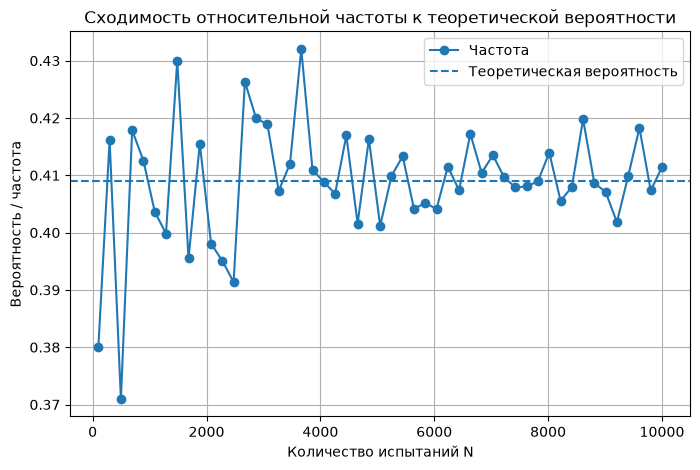

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(N_values, frequencies, marker='o', label='Частота')
plt.axhline(p_theoretical, linestyle='--', label='Теоретическая вероятность')
plt.xlabel('Количество испытаний N')
plt.ylabel('Вероятность / частота')
plt.title('Сходимость относительной частоты к теоретической вероятности')
plt.legend()
plt.grid(True)
plt.show()

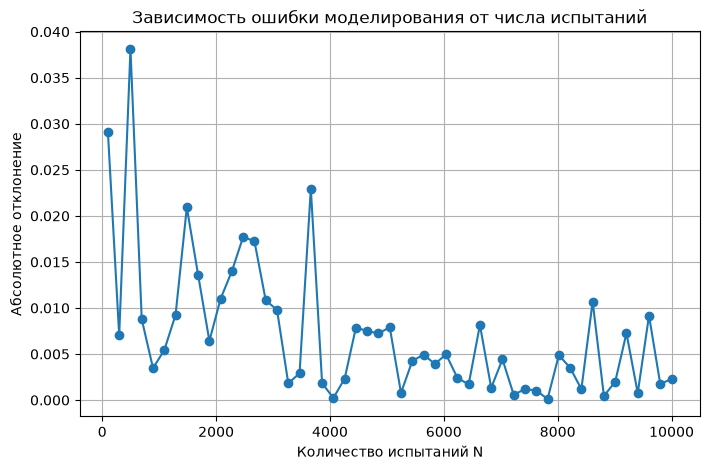

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(N_values, errors, marker='o')
plt.xlabel('Количество испытаний N')
plt.ylabel('Абсолютное отклонение')
plt.title('Зависимость ошибки моделирования от числа испытаний')
plt.grid(True)
plt.show()